In [2]:
# Import libraries
import os
import glob
import numpy as np
import xarray as xr
from scipy import stats
import tensorflow as tf
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cross_decomposition import PLSRegression

os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ["TF_PROFILER_DISABLE_GPU"] = '1'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
tf.get_logger().setLevel('ERROR')
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("Is GPU used for computation?", tf.config.list_physical_devices('GPU') != [])


# === Functions ===
def weighted_spatial(data_array, lats):
    weights = np.cos(np.deg2rad(lats))
    weighted_data = data_array * weights[:, np.newaxis]
    weighted_sum = np.nansum(weighted_data)
    denom = np.nansum(weights) * data_array.shape[1]
    return weighted_sum / denom


def get_data(paths):
    X_MAPS, Y_DATA, model_names = [], [], []
    for path in paths:
        model_name = os.path.splitext(os.path.basename(path))[0]
        model_names.append(model_name)
        with xr.open_dataset(path, chunks={'time': 100}) as ds:
            ds_sel = ds.sel(period=slice(1900, 2050))
            if SAT_SLP:
                sat = ds_sel.X_SAT_SLP[..., 0].values
                slp = ds_sel.X_SAT_SLP[..., 1].values
                X_maps = np.stack([sat, slp], axis=-1)
            else:
                X_maps = ds_sel.X_SAT_SLP[..., 0].values
            Y_data = ds_sel.Y_I_E_SUM.values
        X_MAPS.append(X_maps)
        Y_DATA.append(Y_data)
    return X_MAPS, Y_DATA, model_names


def compute_actual_trends(obs_maps):
    lats = np.arange(-88.75, 88.751, 2.5)
    shape = np.shape(obs_maps)
    actual_trends_all_obs = np.empty((shape[0], shape[1]))
    for combo in range(shape[0]):
        for month in range(shape[1]):
            if SAT_SLP:
                actual_trends_all_obs[combo, month] = weighted_spatial(obs_maps[combo, month, :, :, 0], lats)
            else:
                actual_trends_all_obs[combo, month] = weighted_spatial(obs_maps[combo, month, :], lats)
    print('Mean:  ', round(np.nanmean(actual_trends_all_obs[:, m], axis=0), 3), 'K/dec')
    return actual_trends_all_obs, obs_maps


def prepare_data(splice_X, splice_Y, hist_X, hist_Y, cv, m):
    splice_X_10ens, splice_Y_10ens = [], []
    for idx in range(len(splice_X)):
        random_idxs = tf.random.shuffle(tf.range(tf.shape(splice_X[idx])[0]))[:10]
        splice_X_10ens.append(tf.gather(splice_X[idx][:, :, m], random_idxs))
        splice_Y_10ens.append(tf.gather(splice_Y[idx][:, :, m], random_idxs))
    hist_X_10ens, hist_Y_10ens = [], []
    for idx in range(len(hist_X)):
        random_idxs = tf.random.shuffle(tf.range(tf.shape(hist_X[idx])[0]))[:10]
        hist_X_10ens.append(tf.gather(hist_X[idx][:, :, m], random_idxs))
        hist_Y_10ens.append(tf.gather(hist_Y[idx][:, :, m], random_idxs))

    # Delete the specified index and concatenate, specify for E3SM-2-0
    if no_E3SM:
        if cv == 0:
            X_train_spliced = tf.concat([splice_X_10ens[i] for i in range(tf.shape(splice_X_10ens)[0])], axis=0)
            Y_train_spliced = tf.concat([splice_Y_10ens[i] for i in range(tf.shape(splice_Y_10ens)[0])], axis=0)
        else:
            X_train_spliced = tf.concat([splice_X_10ens[i] for i in range(tf.shape(splice_X_10ens)[0]) if i != cv], axis=0)
            Y_train_spliced = tf.concat([splice_Y_10ens[i] for i in range(tf.shape(splice_Y_10ens)[0]) if i != cv], axis=0)
    else:
        X_train_spliced = tf.concat([splice_X_10ens[i] for i in range(tf.shape(splice_X_10ens)[0]) if i != cv], axis=0)
        Y_train_spliced = tf.concat([splice_Y_10ens[i] for i in range(tf.shape(splice_Y_10ens)[0]) if i != cv], axis=0)

    # Concatenate the hist tensors
    X_train_hist = tf.concat(hist_X_10ens, axis=0)
    Y_train_hist = tf.concat(hist_Y_10ens, axis=0)

    # Reshape to flatten first two dims (ensemble + time)
    def reshape_flat(tensor):
        shape = tf.shape(tensor)
        new_shape = tf.concat([[-1], shape[2:]], axis=0)
        return tf.reshape(tensor, new_shape)

    X_train_spliced = reshape_flat(X_train_spliced)
    X_train_hist = reshape_flat(X_train_hist)
    Y_train_spliced = tf.reshape(Y_train_spliced, [-1, tf.shape(Y_train_spliced)[2]])
    Y_train_hist = tf.reshape(Y_train_hist, [-1, tf.shape(Y_train_hist)[2]])
    X_train = tf.concat([X_train_spliced, X_train_hist], axis=0)
    Y_train = tf.concat([Y_train_spliced, Y_train_hist], axis=0)
    return X_train, Y_train

Num GPUs Available:  1
Is GPU used for computation? True


In [8]:
# Get user input as number
m = int(input("Enter month number (March=2, April=3, May=4): "))
months = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

region = 'Global'
SAT_SLP = False
no_E3SM = True

print('\nRegion:', region)
print('Month: ', months[m])

# === Load observation data ===
sat_paths = np.sort(glob.glob('/glade/work/skygale/training-data/monthly/observations/sat/*.nc'))[::-1]
slp_paths = glob.glob('/glade/work/skygale/training-data/monthly/observations/slp/*')

obs_maps = []
if SAT_SLP:
    for sat_path in sat_paths:
        X_maps_sat = xr.load_dataset(sat_path).DATA
        for slp_path in slp_paths:
            X_maps_slp = xr.load_dataset(slp_path).DATA
            combined = np.stack([X_maps_sat.values, X_maps_slp.values], axis=-1)
            obs_maps.append(combined)
else:
    for sat_path in sat_paths:
        X_maps_sat = xr.load_dataset(sat_path).DATA
        obs_maps.append(X_maps_sat)

obs_maps = np.array(obs_maps)
actual_trends_obs_means, obs_maps = compute_actual_trends(obs_maps)

# === Load simulated data ===
spliced_path = '/glade/work/skygale/training-data/monthly/spliced/'
hist_path = '/glade/work/skygale/training-data/monthly/hist/'
spliced = glob.glob(spliced_path+region.lower()+'/*')
hist = glob.glob(hist_path+region.lower()+'/*')

spliced = [model for model in spliced if 'OthersAllEM.nc' not in model]
hist = [model for model in hist if 'OthersAllEM.nc' not in model]

splice_X, splice_Y, model_names_spliced_old = get_data(spliced)
hist_X, hist_Y, model_names_hist = get_data(hist)

# === Reorganize models by warming indices ===
models_reorganized = [
    'E3SM-2-0',
    'CanESM5',
    'MIROC6',
    'MPI-ESM1-2-LR',
    'IPSL-CM6A-LR',
    'ACCESS-ESM1-5',
    'CESM2',
    'CESM2_SMBB'
]
ranked_warming_indices = [model_names_spliced_old.index(name) for name in models_reorganized]
splice_X_array = [splice_X[i] for i in ranked_warming_indices]
splice_Y_array = [splice_Y[i] for i in ranked_warming_indices]
model_names_spliced = [model_names_spliced_old[i] for i in ranked_warming_indices]

# === Convert into PyTorch tensors ===
splice_X, splice_Y = [], []
[splice_X.append(tf.convert_to_tensor(splice_X_array[i])) for i in range(len(splice_X_array))]
[splice_Y.append(tf.convert_to_tensor(splice_Y_array[i])) for i in range(len(splice_Y_array))]
obs_maps = tf.convert_to_tensor(obs_maps)

# === Check data we are using for training ===
print('\nData shapes (splice_X, splice_Y):')
for i, splice in enumerate(splice_X):
    print(i+1, np.shape(splice), model_names_spliced[i])
for i, splice in enumerate(splice_Y):
    print(i+1, np.shape(splice), model_names_spliced[i])

# Remove E3SMv2 from training data
if no_E3SM:
    print('\n==> E3SM not included in training data.')
    splice_X_cut = splice_X[1:]
    splice_Y_cut = splice_Y[1:]
    model_names_spliced_cut = model_names_spliced[1:]

    print('\nData shapes (splice_X_cut, splice_Y_cut):')
    for i, splice in enumerate(splice_X_cut):
        print(i+1, np.shape(splice), model_names_spliced_cut[i])
    for i, splice in enumerate(splice_Y_cut):
        print(i+1, np.shape(splice), model_names_spliced_cut[i])
else:
    print('\n==> E3SM included in training data.')

print('\nDone loading data.\n')

Enter month number (March=2, April=3, May=4):  4



Region: Global
Month:  May
Mean:   0.172 K/dec

Data shapes (splice_X, splice_Y):
1 (21, 22, 12, 72, 144) E3SM-2-0
2 (25, 22, 12, 72, 144) CanESM5
3 (50, 22, 12, 72, 144) MIROC6
4 (10, 22, 12, 72, 144) MPI-ESM1-2-LR
5 (11, 22, 12, 72, 144) IPSL-CM6A-LR
6 (25, 22, 12, 72, 144) ACCESS-ESM1-5
7 (50, 22, 12, 72, 144) CESM2
8 (50, 22, 12, 72, 144) CESM2_SMBB
1 (21, 22, 12, 3) E3SM-2-0
2 (25, 22, 12, 3) CanESM5
3 (50, 22, 12, 3) MIROC6
4 (10, 22, 12, 3) MPI-ESM1-2-LR
5 (11, 22, 12, 3) IPSL-CM6A-LR
6 (25, 22, 12, 3) ACCESS-ESM1-5
7 (50, 22, 12, 3) CESM2
8 (50, 22, 12, 3) CESM2_SMBB

==> E3SM not included in training data.

Data shapes (splice_X_cut, splice_Y_cut):
1 (25, 22, 12, 72, 144) CanESM5
2 (50, 22, 12, 72, 144) MIROC6
3 (10, 22, 12, 72, 144) MPI-ESM1-2-LR
4 (11, 22, 12, 72, 144) IPSL-CM6A-LR
5 (25, 22, 12, 72, 144) ACCESS-ESM1-5
6 (50, 22, 12, 72, 144) CESM2
7 (50, 22, 12, 72, 144) CESM2_SMBB
1 (25, 22, 12, 3) CanESM5
2 (50, 22, 12, 3) MIROC6
3 (10, 22, 12, 3) MPI-ESM1-2-LR
4 (11, 22

Number of components: 1
  Cross validation: E3SM-2-0
  Cross validation: CanESM5
  Cross validation: MIROC6
  Cross validation: MPI-ESM1-2-LR
  Cross validation: IPSL-CM6A-LR
  Cross validation: ACCESS-ESM1-5
  Cross validation: CESM2
  Cross validation: CESM2_SMBB


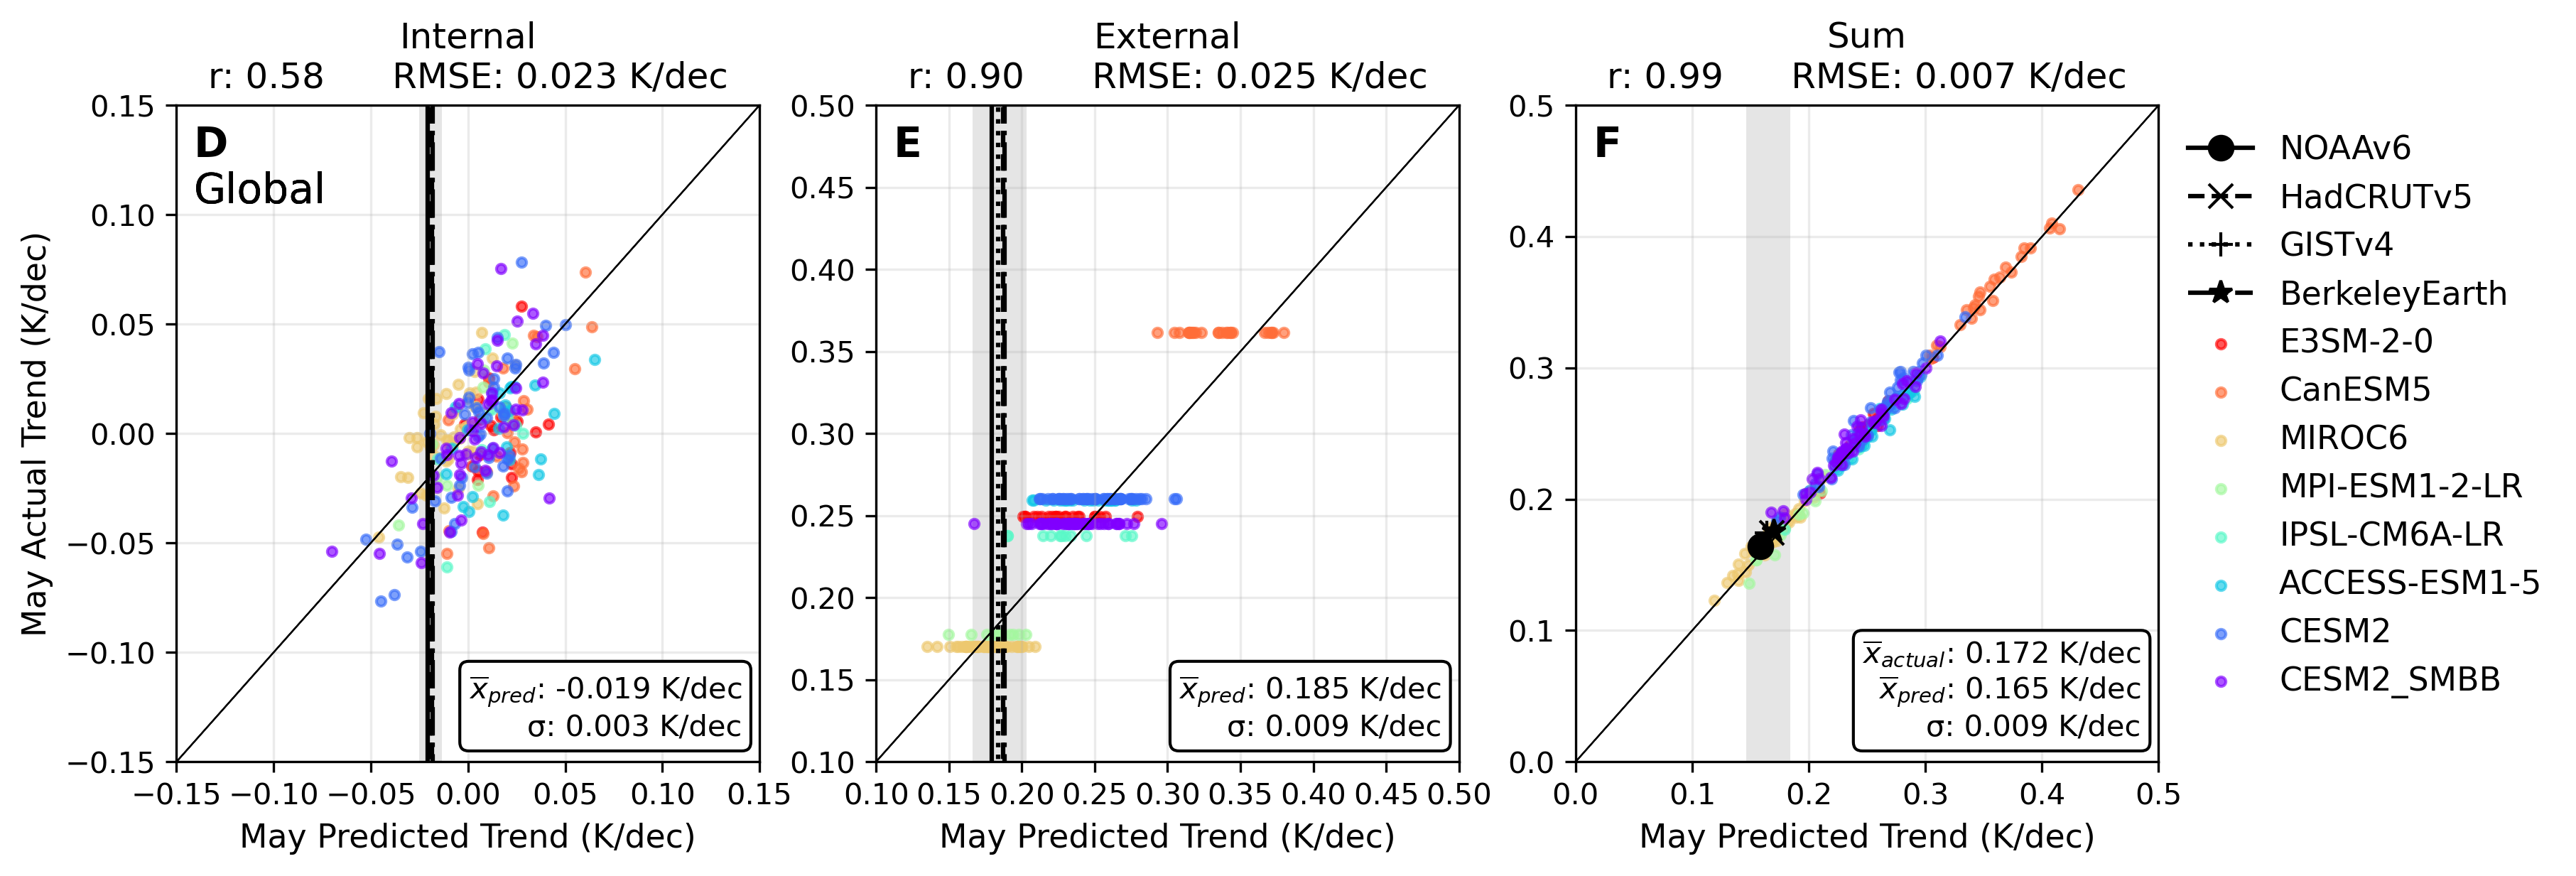

Number of components: 2
  Cross validation: E3SM-2-0
  Cross validation: CanESM5
  Cross validation: MIROC6
  Cross validation: MPI-ESM1-2-LR
  Cross validation: IPSL-CM6A-LR
  Cross validation: ACCESS-ESM1-5
  Cross validation: CESM2
  Cross validation: CESM2_SMBB


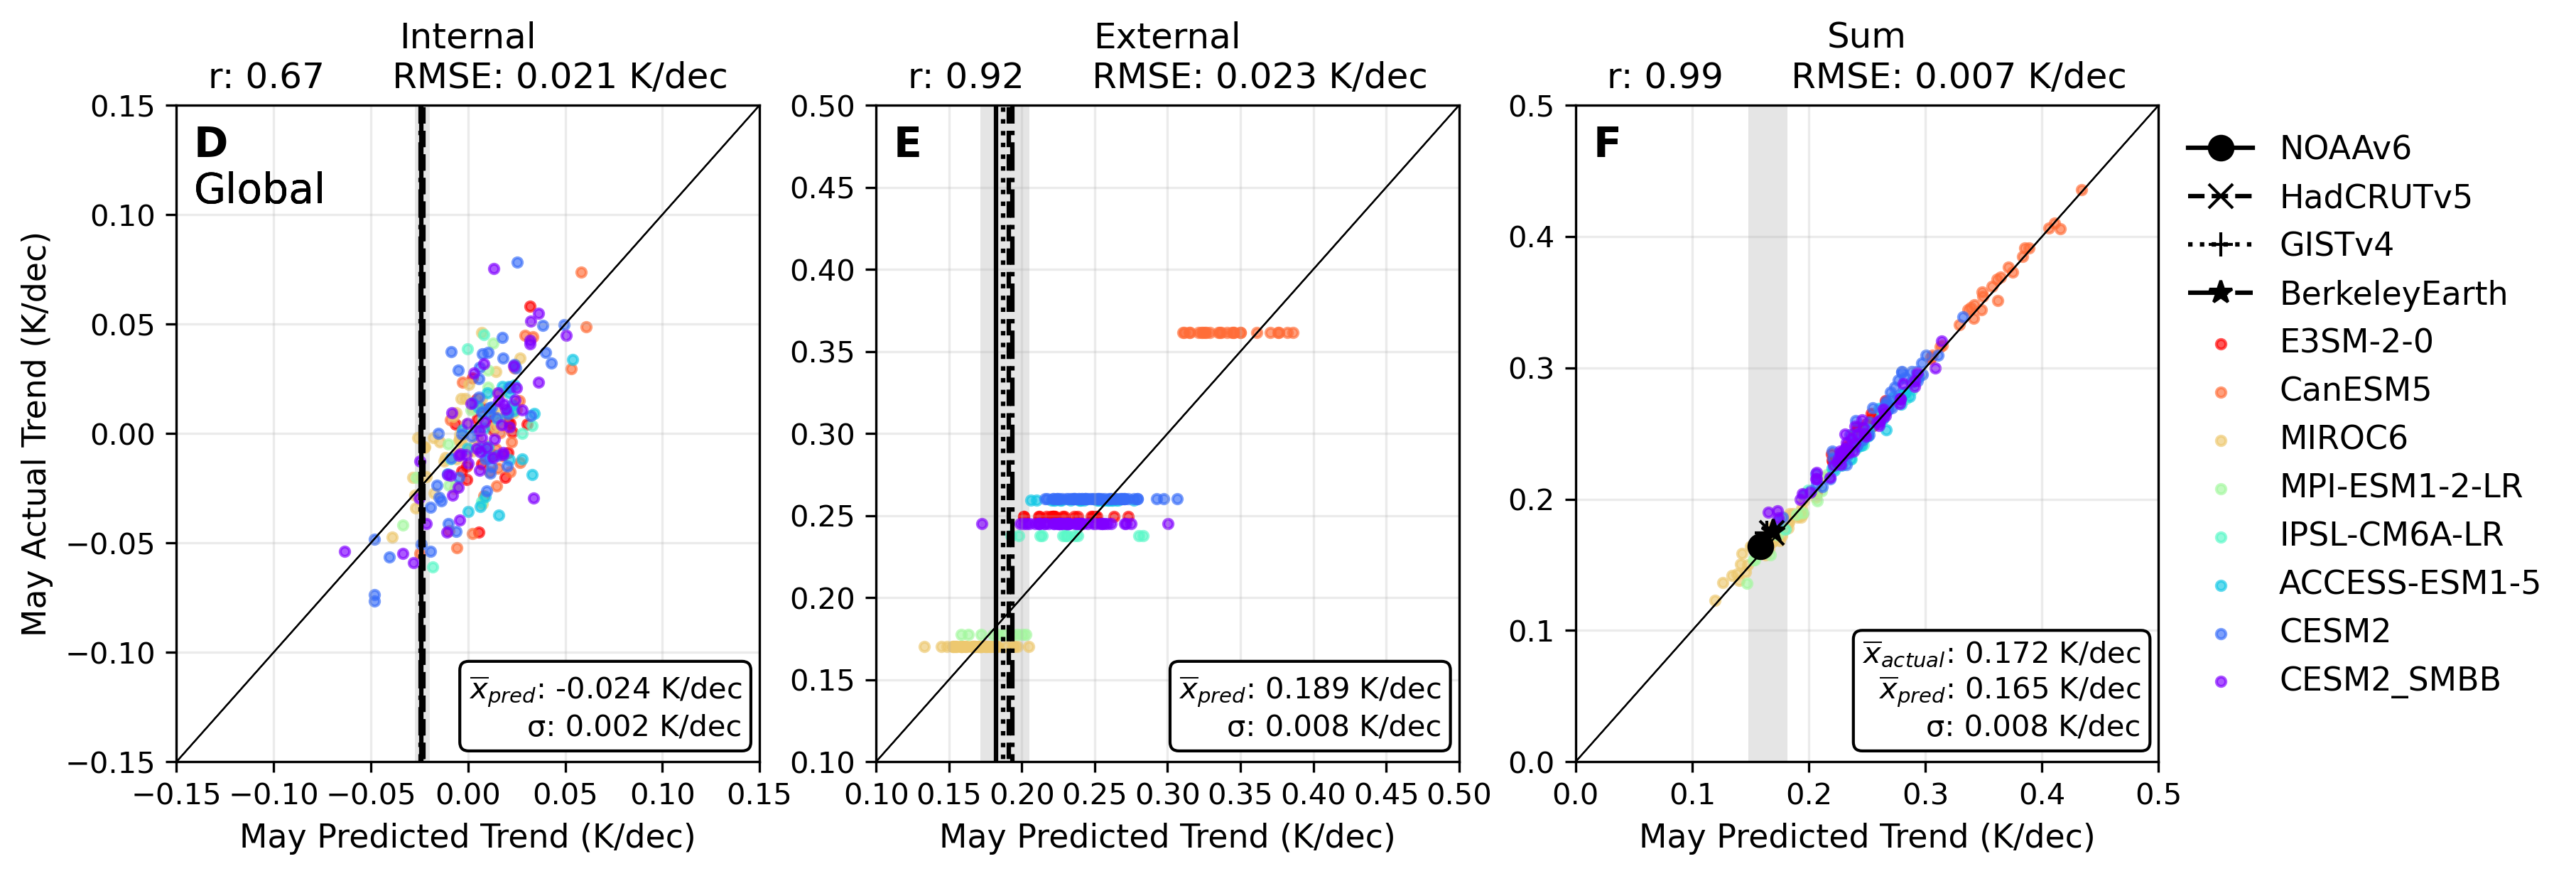

Number of components: 3
  Cross validation: E3SM-2-0
  Cross validation: CanESM5
  Cross validation: MIROC6
  Cross validation: MPI-ESM1-2-LR
  Cross validation: IPSL-CM6A-LR
  Cross validation: ACCESS-ESM1-5
  Cross validation: CESM2
  Cross validation: CESM2_SMBB


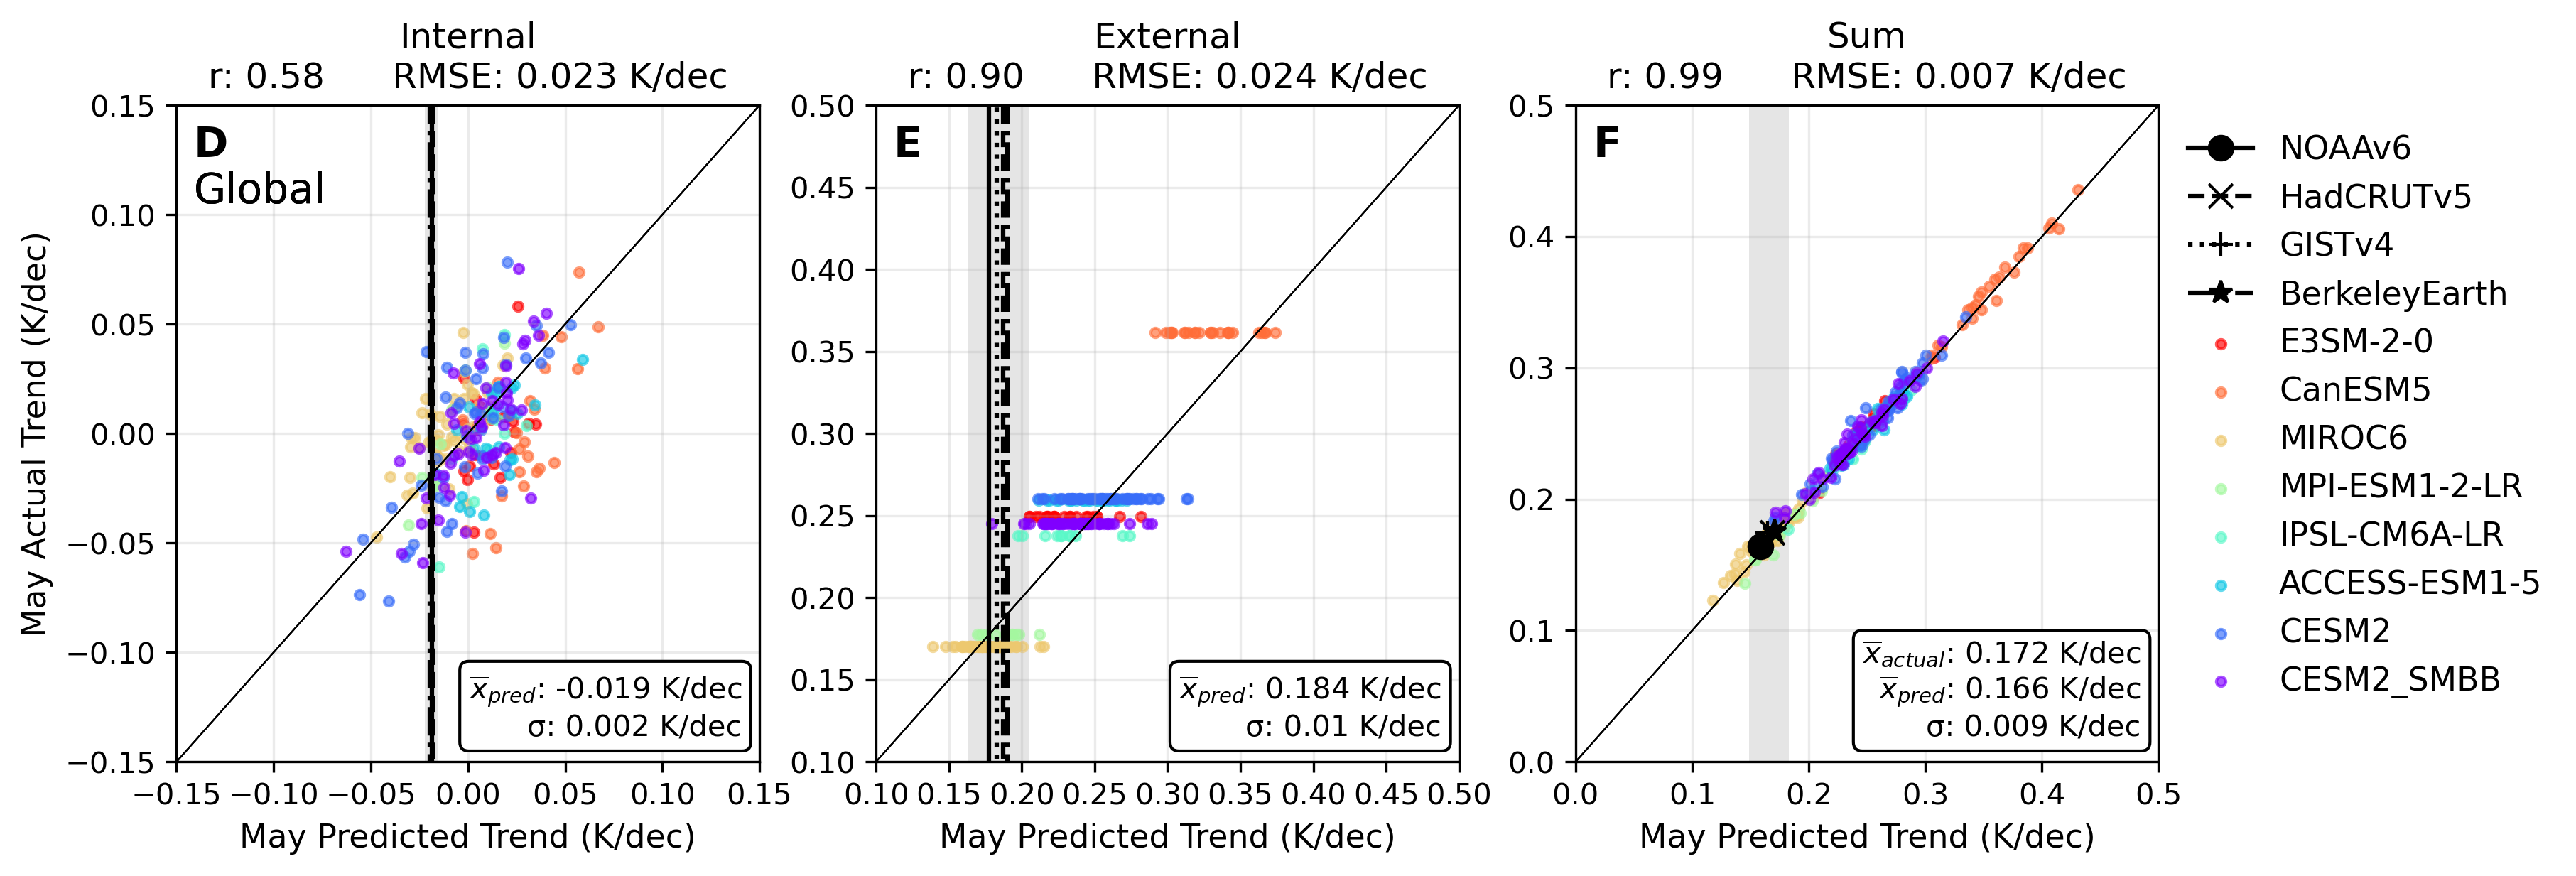

Number of components: 4
  Cross validation: E3SM-2-0
  Cross validation: CanESM5
  Cross validation: MIROC6
  Cross validation: MPI-ESM1-2-LR
  Cross validation: IPSL-CM6A-LR
  Cross validation: ACCESS-ESM1-5
  Cross validation: CESM2
  Cross validation: CESM2_SMBB


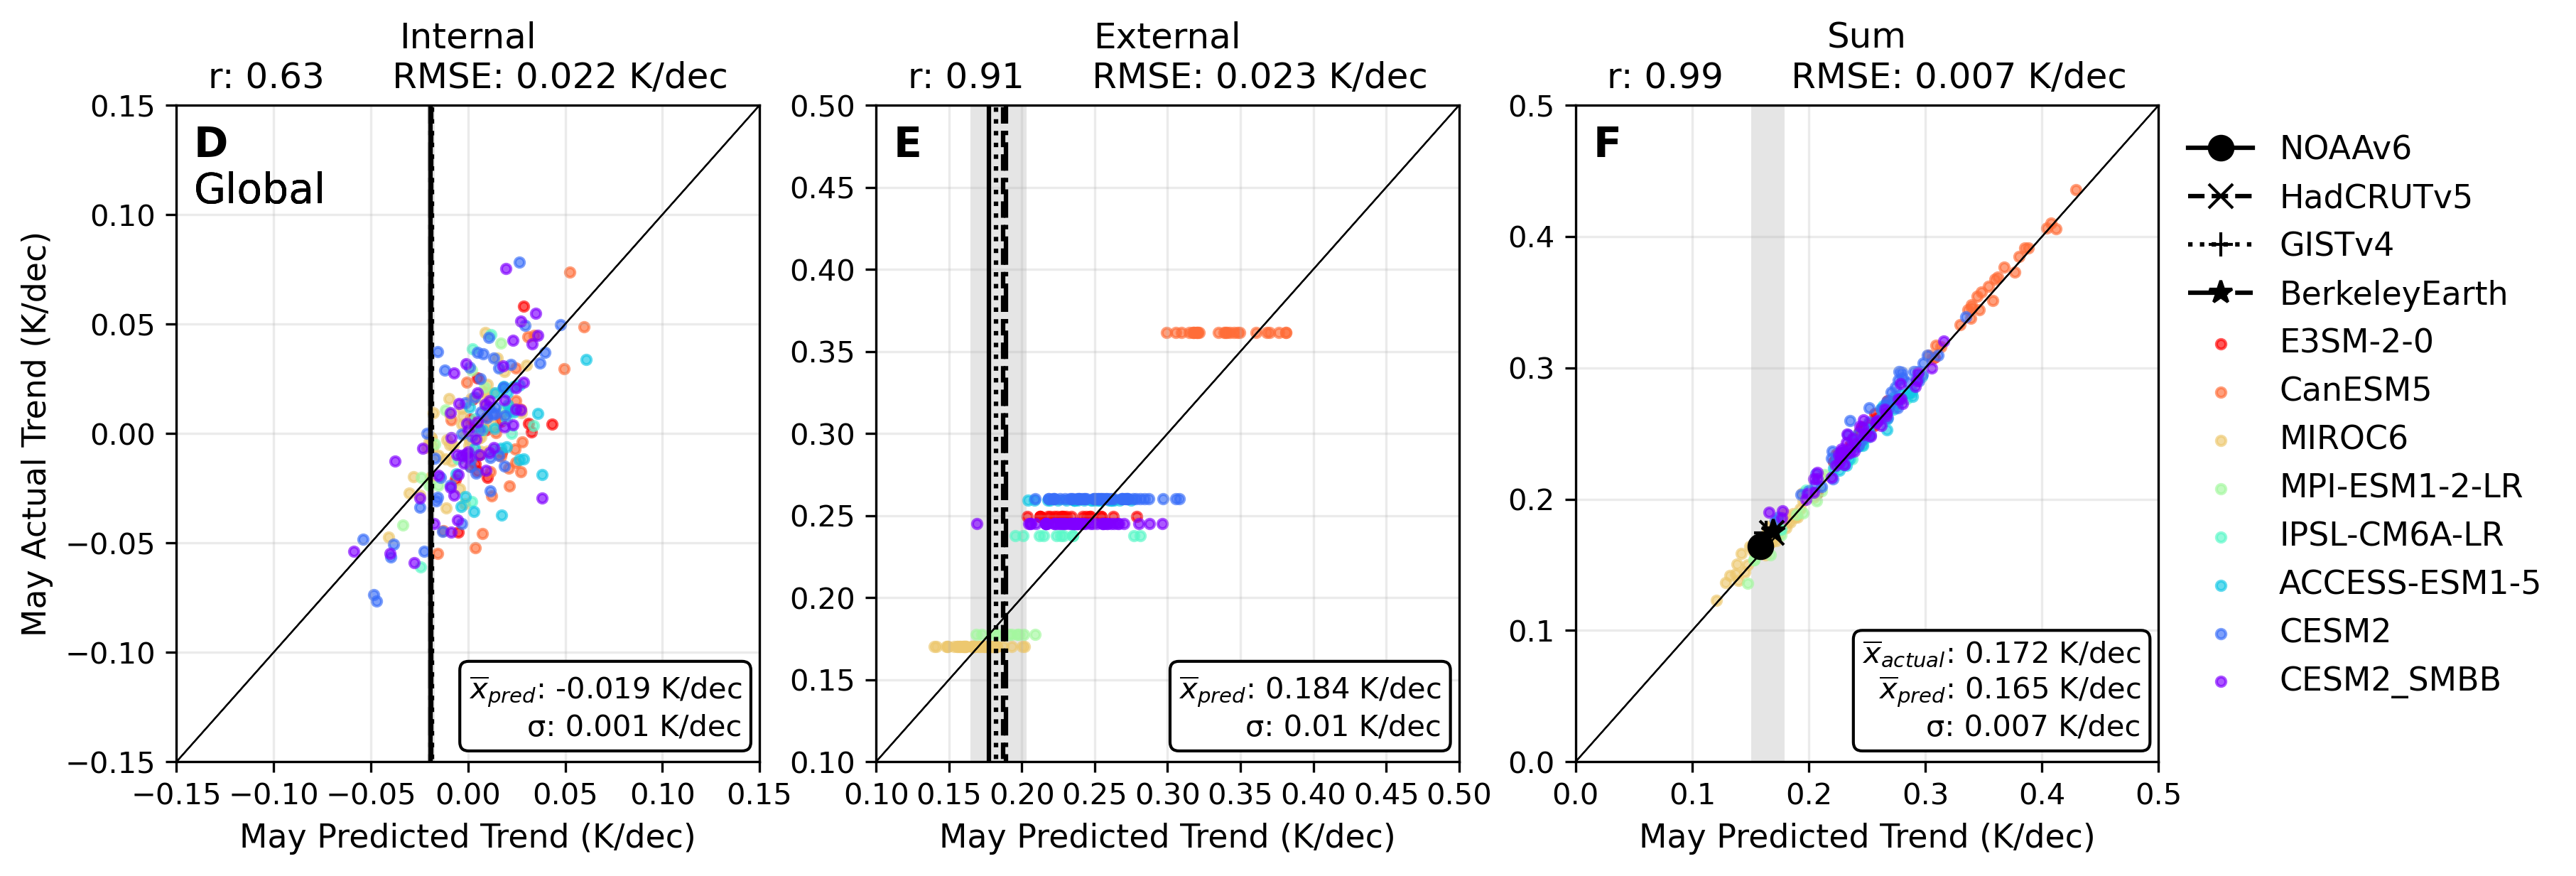

Number of components: 5
  Cross validation: E3SM-2-0
  Cross validation: CanESM5
  Cross validation: MIROC6
  Cross validation: MPI-ESM1-2-LR
  Cross validation: IPSL-CM6A-LR
  Cross validation: ACCESS-ESM1-5
  Cross validation: CESM2
  Cross validation: CESM2_SMBB


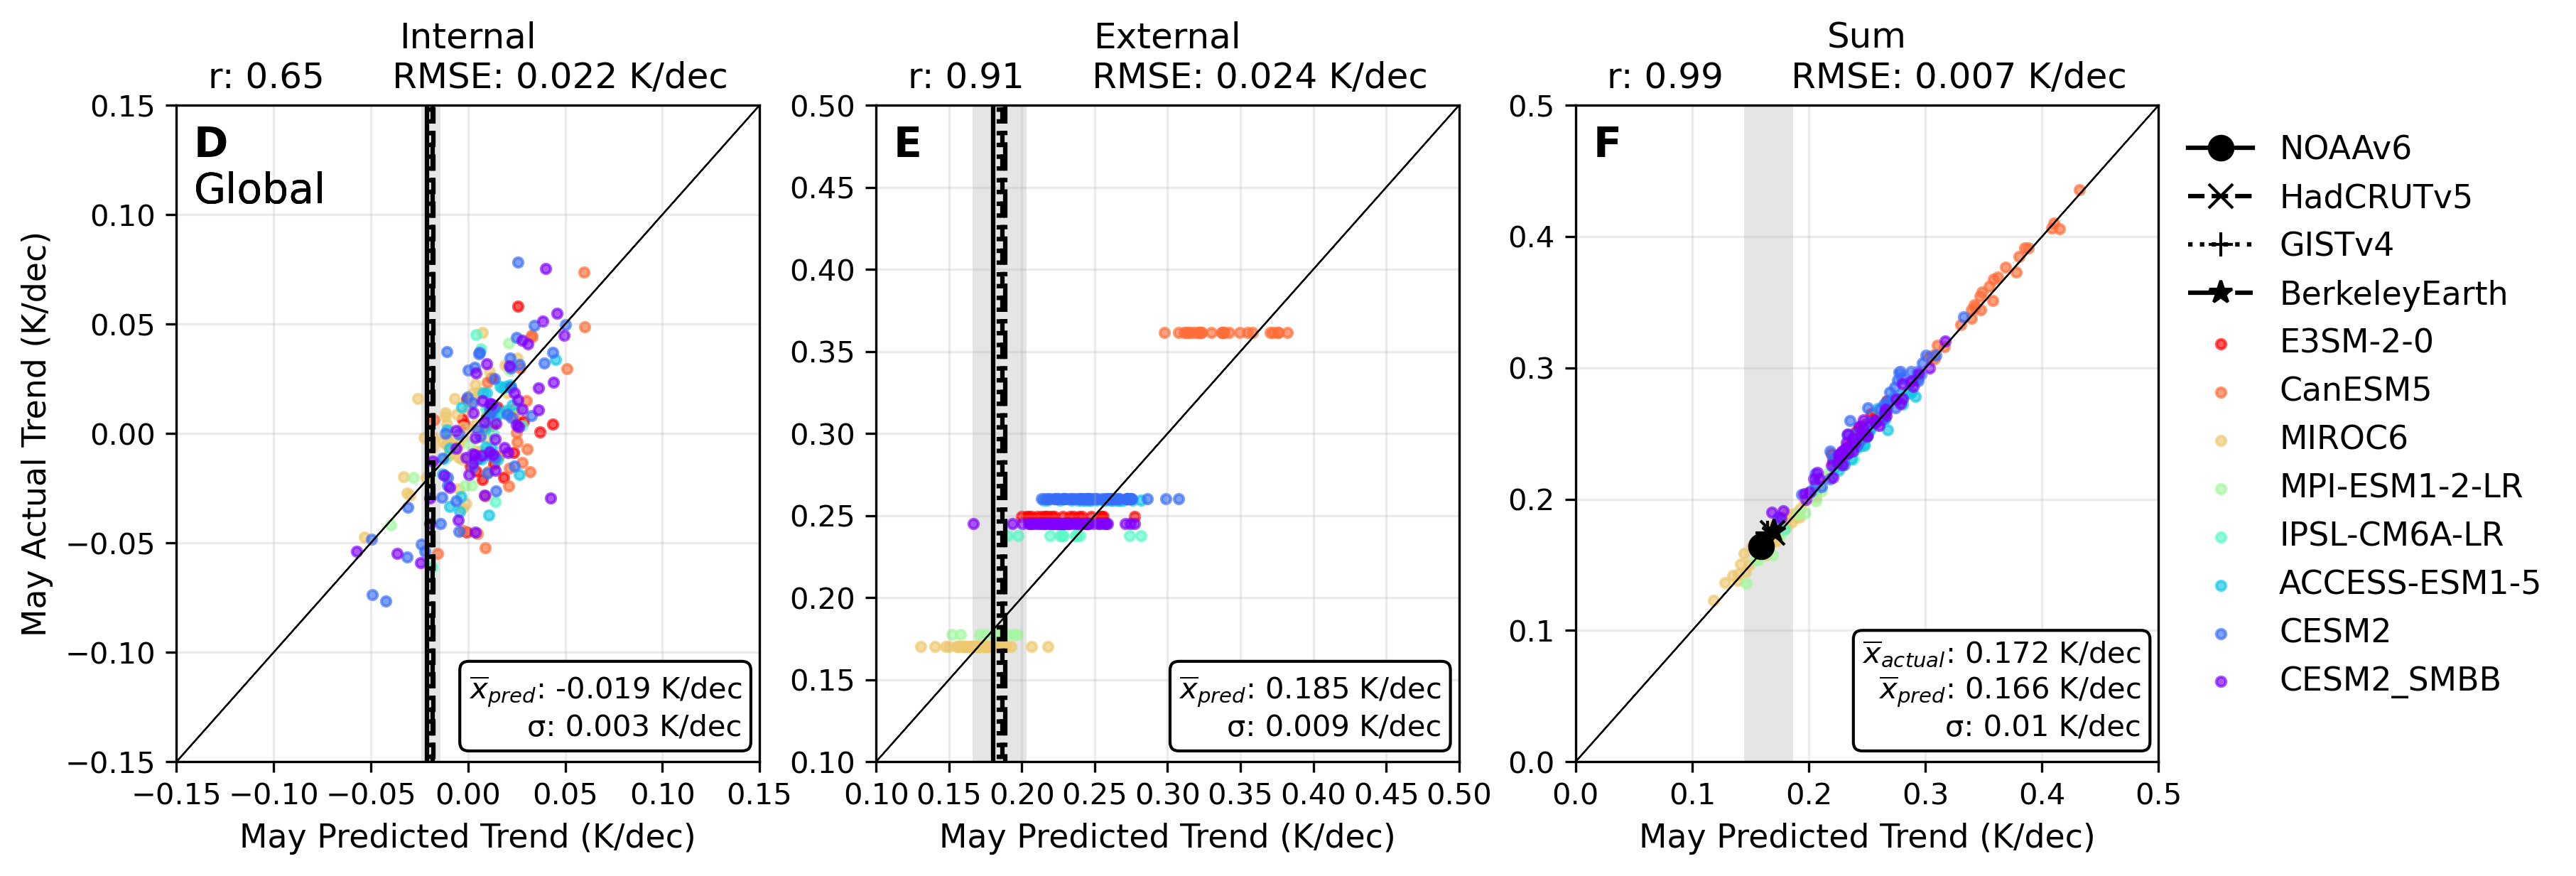

Done!


In [9]:
# Scalers
Xscale = MinMaxScaler()
Yscale = MinMaxScaler()

# Settings
titles = ['Internal', 'External', 'Sum']
obs_labels = ['NOAAv6', 'HadCRUTv5', 'GISTv4', 'BerkeleyEarth']
obs_markers = ['o', 'x', '+', '*']
linestyles = ['-', '--', ':', '-.']
colors = cm.rainbow(np.linspace(0, 1, 8))[::-1]
bbox = dict(facecolor='white', ec='black', boxstyle='round')
ticks = np.arange(-0.15, 0.151, 0.05), np.arange(0.1, 0.51, 0.05), np.arange(0, 0.51, 0.1)
top = 0.02

with tf.device('/GPU:0'):

    for n_components in range(1, 6):
        print('Number of components:', n_components)

        # Create arrays for which to store result
        cv_preds_and_vals = []
        cv_obs = []
        cv_mse = []
        prediction_error = []

        # Loop through each large ensemble we test on
        for cv in range(len(splice_X)):
            print('  Cross validation:', model_names_spliced[cv])

            # Define training data
            X_train, Y_train = prepare_data(splice_X, splice_Y, hist_X, hist_Y, cv, m)

            # Reshape to (samples, features)
            X_train_reshaped = tf.reshape(X_train, [tf.shape(X_train)[0], -1]).numpy()
            Y_train_reshaped = Y_train[:, :2].numpy()

            # Define testing data
            X_test = splice_X[cv][:, -6, m]
            X_test_reshaped = tf.reshape(X_test, (tf.shape(X_test)[0], -1)).numpy()
            Y_test_reshaped = splice_Y[cv][:, -6, m, :2].numpy()

            # Scale training and testing data
            Xscale.fit(X_train_reshaped)
            Yscale.fit(Y_train_reshaped)
            X_train_scaled = Xscale.transform(X_train_reshaped)
            Y_train_scaled = Yscale.transform(Y_train_reshaped)
            X_test_scaled = Xscale.transform(X_test_reshaped)

            # Train PLS model
            pls = PLSRegression(n_components=5)  # <-- tune this
            pls.fit(X_train_scaled, Y_train_scaled)

            # Predict on test set
            Y_pred_scaled = pls.predict(X_test_scaled)
            Y_preds_unscaled = Yscale.inverse_transform(Y_pred_scaled)

            # Reshape prediction and actual values
            Y_pred = np.transpose(Y_preds_unscaled).tolist()
            Y_test_one_model = np.transpose(Y_test_reshaped).tolist()

            # Append sum values
            Y_pred.append(np.nansum(Y_pred, axis=0))
            Y_test_one_model.append(np.nansum(Y_test_one_model, axis=0))
            cv_preds_and_vals.append([np.transpose(Y_pred), np.transpose(Y_test_one_model)])

            # Compute error
            error = np.array(Y_pred) - np.array(Y_test_one_model)
            prediction_error.append(error)
            mse_of_cv = [np.mean((error[i])**2) for i in range(3)]
            cv_mse.append(mse_of_cv)

            # Predict on observations
            obs_map = obs_maps[:, m]
            X_obs_reshaped = tf.reshape(obs_map, (tf.shape(obs_map)[0], -1)).numpy()
            X_obs_scaled = Xscale.transform(X_obs_reshaped)
            obs_Y_pred_scaled = pls.predict(X_obs_scaled)
            obs_Y_pred_unscaled = Yscale.inverse_transform(obs_Y_pred_scaled)

            Y_obs = np.transpose(obs_Y_pred_unscaled).tolist()
            Y_obs.append(np.nansum(Y_obs, axis=0))
            cv_obs.append(Y_obs)

        new_errors = []
        for error in prediction_error:
            squared_error = np.multiply(error, error)
            new_errors.append(squared_error/len(squared_error))
        new_errors_all = np.concatenate(new_errors, axis=1)
        new_errors_sum = np.nansum(new_errors_all, 0)
        new_errors_std = np.sqrt(new_errors_sum/8)

        # Figure
        fig, axs = plt.subplots(1, 3, figsize=(12, 4), dpi=300, facecolor='white')
        obs_actual = str(np.round(np.nanmean(actual_trends_obs_means, axis=0), 3)[m])
        cv_preds_and_vals_ = cv_preds_and_vals
        cv_obs_ = np.swapaxes(np.array(cv_obs), 0, 2)

        for i in range(3):
            axs[0].text(0.03, 0.9, f'{region}', fontsize=14, transform=axs[0].transAxes, va='top', ha='left')
            all_obs_spread = np.nanmean(cv_obs_[:, i, :], 1).ravel()
            obs_mean = np.nanmean(all_obs_spread)
            sigma_obs = np.nanstd(all_obs_spread)
            sigma_cnn = new_errors_std[i]
            sigma = np.sqrt(sigma_obs**2+sigma_cnn**2)
            axs[i].axvspan(obs_mean-2*sigma, obs_mean+2*sigma, color='grey', alpha=0.2, ec=None)
            cv_obs_set = cv_obs_[:, i, :].reshape(4, 8)
            mean = str(round(obs_mean, 3))
            std = str(round(sigma, 3))

            if i in [0, 1]:
                text = '$\overline{x}$$_{pred}$: '+mean+' K/dec\nσ: '+std+' K/dec'
                axs[i].text(0.97, 0.03, text, transform=axs[i].transAxes, fontsize=10, va='bottom', ha='right', bbox=bbox)
                for idx in range(len(cv_obs_set)):
                    obs_set_all_cv = cv_obs_set[idx]
                    mean_obs = np.nanmean(obs_set_all_cv)
                    axs[i].plot(np.repeat(mean_obs, 3), [-5, 0.3, 5], linestyle=linestyles[idx], linewidth=1.5, color='k', label=obs_labels[idx])
            else:
                text = '$\overline{x}$$_{actual}$: '+obs_actual+' K/dec'+'\n$\overline{x}$$_{pred}$: '+mean+' K/dec\nσ: '+std+' K/dec'
                axs[i].text(0.97, 0.03, text, transform=axs[i].transAxes, fontsize=10,  va='bottom', ha='right', bbox=bbox)
                for idx in range(len(cv_obs_set)):
                    obs_set_all_cv = cv_obs_set[idx]
                    mean_obs = np.nanmean(obs_set_all_cv)
                    axs[i].plot(mean_obs, actual_trends_obs_means[:, m][idx], linestyle=linestyles[idx], marker=obs_markers[idx], markersize=8, color='k', label=obs_labels[idx])

        for model_idx, set_of_preds_and_vals in enumerate(cv_preds_and_vals_):
            Y_pred = np.array(set_of_preds_and_vals[0])
            Y_test = np.array(set_of_preds_and_vals[1])
            for i in range(3):
                axs[i].scatter(Y_pred[:, i], Y_test[:, i], color=colors[model_idx], s=10, alpha=0.65, label=model_names_spliced[model_idx])
                axs[i].axline((0, 0), slope=1, color='k', alpha=0.5, linewidth=0.5)
                axs[i].set_xticks(ticks[i])
                axs[i].set_yticks(ticks[i])
                axs[i].set_ylim(ticks[i][0], ticks[i][-1])
                axs[i].set_xlim(ticks[i][0], ticks[i][-1])

        all_preds_and_vals = np.concatenate(cv_preds_and_vals_, axis=1)
        labels = ['D', 'E', 'F']

        for i in range(3):
            axs[i].text(0.03, 0.97, labels[i], fontsize=14, transform=axs[i].transAxes, va='top', ha='left', fontweight='bold')
            Y_pred = all_preds_and_vals[0]
            Y_test = all_preds_and_vals[1]
            MSE = np.nanmean(np.square(Y_pred[:, i]-Y_test[:, i]), 0)
            MSE_str = str(np.around(MSE, 5))
            r = stats.pearsonr(Y_pred[:, i], Y_test[:, i])[0]
            r_str = str(np.around(r, 3))
            axs[i].set_title(titles[i]+'\nr: {:.2f}'.format(round(r, 2))+'      RMSE: {:.3f} K/dec'.format(round(np.sqrt(MSE), 3)), fontsize=12)
            axs[i].set_xlabel(f'{months[m]} Predicted Trend (K/dec)', fontsize=11)
            axs[0].set_ylabel(f'{months[m]} Actual Trend (K/dec)', fontsize=11)
            axs[i].grid(alpha=0.25)
            axs[i].tick_params(axis='both', which='major', labelsize=10)
            axs[i].tick_params(axis='both', which='minor', labelsize=10)

        axs[2].legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False, fontsize=11)
        plt.savefig(f'./figures/PLS_{region}_{months[m]}_{n_components}.png', dpi=300)
        plt.show()

print('Done!')